In [1]:
!pip install mlflow

In [4]:
import dagshub
dagshub.init(repo_owner='Sovith07', repo_name='yt_comment_analyzer', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=a6e78945-1e3b-4f85-9651-eb33c75a8fc2&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=739966999b412641a98226f05673ad99d72993fabd5afa0196710fceb58644d6




Accessing as Sovith07

Initialized MLflow to track repo "Sovith07/yt_comment_analyzer"

Repository Sovith07/yt_comment_analyzer initialized!

In [5]:
import mlflow

mlflow.set_tracking_uri("https://dagshub.com/Sovith07/yt_comment_analyzer.mlflow")

with mlflow.start_run():
    mlflow.log_param("param1", 15)
    mlflow.log_metric("metric1", 0.89)

🏃 View run wistful-whale-228 at: https://dagshub.com/Sovith07/yt_comment_analyzer.mlflow/#/experiments/0/runs/fd776ffe628c48c4924e1ec2a76c7500
🧪 View experiment at: https://dagshub.com/Sovith07/yt_comment_analyzer.mlflow/#/experiments/0


In [2]:
import numpy as np
import pandas as pd

In [34]:
df = pd.read_csv('D:\\vs code projects\\yt_comment_analyzer\\data\\interim\\cleaned_data.csv')
df.head()

,clean_comment,category
0,family mormon never tried explain still stare ...,1.0
1,buddhism much lot compatible christianity espe...,1.0
2,seriously say thing first get complex explain ...,-1.0
3,learned want teach different focus goal not wr...,0.0
4,benefit may want read living buddha living chr...,1.0


In [10]:
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Step 1: Vectorize the comments using Bag of Words (CountVectorizer)
vectorizer = CountVectorizer(max_features=10000)  # Bag of Words model with a limit of 1000 features

In [15]:
df['clean_comment'].isna().sum()

np.int64(194)

In [ ]:
df['category'] = df['category'].astype('category')

np.int64(0)

In [17]:
df.dropna(inplace=True)

In [18]:
df['clean_comment'].isna().sum()

np.int64(0)

In [22]:
X = vectorizer.fit_transform(df['clean_comment'])
y = df['category']  # Assuming 'category' is the target variable (0 or 1 for binary classification)

In [23]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2591968 stored elements and shape (199508, 10000)>

In [24]:
X.shape

(199508, 10000)

In [25]:
y

0         1.0
1         1.0
2        -1.0
3         0.0
4         1.0
         ... 
199697   -1.0
199698   -1.0
199699    0.0
199700    0.0
199701    1.0
Name: category, Length: 199508, dtype: float64

In [26]:
y.shape

(199508,)

In [27]:
# Set or create an experiment
mlflow.set_experiment("RF Baseline")

2026/08/16 00:17:04 INFO mlflow.tracking.fluent: Experiment with name 'RF Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/0e436e90096a4b08b43577124e50e49c', creation_time=1786819624589, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786819624589, lifecycle_stage='active', name='RF Baseline', tags={}, trace_location=None, workspace='default'>

2026/08/16 00:22:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/16 00:22:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run RandomForest_Baseline_TrainTestSplit at: https://dagshub.com/Sovith07/yt_comment_analyzer.mlflow/#/experiments/1/runs/0864076c21f845a59824843d32bb44f6
🧪 View experiment at: https://dagshub.com/Sovith07/yt_comment_analyzer.mlflow/#/experiments/1
Accuracy: 0.4425342088115884


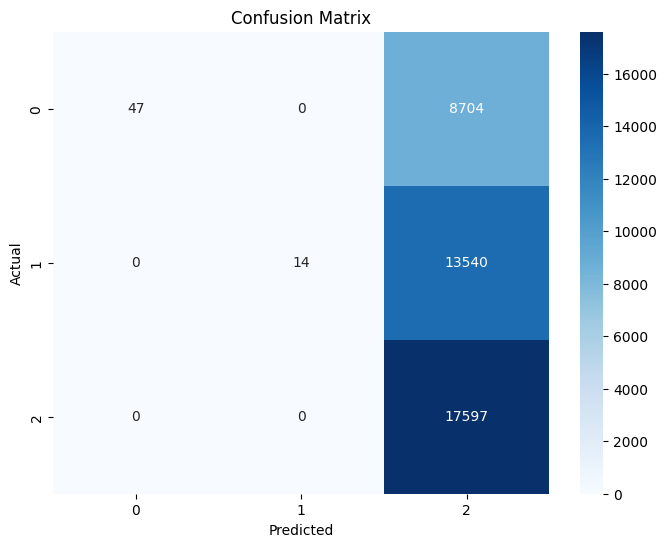

In [31]:
# Step 1: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Define and train a Random Forest baseline model using a simple train-test split
with mlflow.start_run() as run:
    # Log a description for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    # Add a description
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    # Log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)

    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # Initialize and train the model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("D:\\vs code projects\\yt_comment_analyzer\\artifacts\\confusion_matrix.png")
    mlflow.log_artifact("D:\\vs code projects\\yt_comment_analyzer\\artifacts\\confusion_matrix.png")

    # Log the Random Forest model
    mlflow.sklearn.log_model(model, "random_forest_model")

    # Optionally log the dataset itself (if it's small enough)
    df.to_csv("D:\\vs code projects\\yt_comment_analyzer\\artifacts\\dataset.csv", index=False)
    mlflow.log_artifact("D:\\vs code projects\\yt_comment_analyzer\\artifacts\\dataset.csv")

# Display final accuracy
print(f"Accuracy: {accuracy}")

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       1.00      0.01      0.01      8751
         0.0       1.00      0.00      0.00     13554
         1.0       0.44      1.00      0.61     17597

    accuracy                           0.44     39902
   macro avg       0.81      0.34      0.21     39902
weighted avg       0.75      0.44      0.27     39902



In [35]:
df.to_csv(r'D:\vs code projects\yt_comment_analyzer\data\processed\final_data.csv', index=False)